# Thống kê

In [ ]:
# %% [markdown]
# # 📊 Phân tích hành vi mua sắm của Cold-Start Users
# Notebook này giúp xác định Cold-start users và thống kê xem họ thực sự mua gì (Ground Truth).

# %%
import pandas as pd
import numpy as np
import pickle
import joblib
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình hiển thị
pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")

# %% [markdown]
# ## 1. Cấu hình Đường dẫn

# %%
# ĐƯỜNG DẪN (Sửa lại cho đúng máy bạn)
PATH_GT = "./data/final_groundtruth.pkl" 
PATH_MODEL_S1 = "./artifacts/stage1_model_base.pkl" 
PATH_ITEM_DIR = "./data/preprocessed-dataset-news" 

print(f"Checking paths...")
print(f"GT Exists: {os.path.exists(PATH_GT)}")
print(f"Model Exists: {os.path.exists(PATH_MODEL_S1)}")
print(f"Item Dir Exists: {os.path.exists(PATH_ITEM_DIR)}")

# %% [markdown]
# ## 2. Hàm Load Dữ liệu

# %%
def load_groundtruth_pkl(path):
    """Load Ground Truth xử lý mọi định dạng."""
    print(f"Loading GT from {path}...")
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    gt_clean = {}
    
    # Xử lý nếu là DataFrame
    if isinstance(data, pd.DataFrame):
        data['customer_id'] = data['customer_id'].astype(str)
        if isinstance(data['item_id'].iloc[0], (list, np.ndarray, set)):
            data = data.explode('item_id')
        data['item_id'] = data['item_id'].astype(str)
        gt_clean = data.groupby('customer_id')['item_id'].apply(list).to_dict()
        
    # Xử lý nếu là Dict
    elif isinstance(data, dict):
        for k in ['gt_test', 'test', 'groundtruth']:
            if k in data: data = data[k]; break
        for u, v in data.items():
            items = v if isinstance(v, (list, set, tuple)) else [v]
            gt_clean[str(u)] = [str(x) for x in items]
            
    return gt_clean

def load_item_metadata(data_dir):
    """Load thông tin sản phẩm an toàn (chỉ load cột có thật)."""
    print("Loading Item Metadata...")
    files = glob.glob(os.path.join(data_dir, "*item_chunk*.parquet"))
    if not files:
        raise FileNotFoundError("Không tìm thấy file item parquet!")
    
    # Danh sách cột mong muốn (Ưu tiên)
    wanted_cols = [
        "item_id", 
        "item_name", "name", "title", # Các biến thể tên
        "brand", "brand_final", 
        "category", "category_l1", "category_l2", "category_l3", 
        "price"
    ]
    
    # Kiểm tra cột thực tế trong file đầu tiên
    sample_cols = pd.read_parquet(files[0]).columns.tolist()
    use_cols = [c for c in wanted_cols if c in sample_cols]
    
    print(f"-> Columns found in parquet: {use_cols}")
    
    df_list = []
    for f in files:
        try:
            df_chunk = pd.read_parquet(f, columns=use_cols)
            df_list.append(df_chunk)
        except Exception as e:
            print(f"Skipping {f}: {e}")
            
    df_item = pd.concat(df_list, ignore_index=True)
    df_item['item_id'] = df_item['item_id'].astype(str)
    
    # Drop duplicates
    df_item = df_item.drop_duplicates(subset=['item_id'])
    
    # Fill NA cho các cột phân loại
    cat_cols = [c for c in use_cols if 'category' in c or 'brand' in c]
    df_item[cat_cols] = df_item[cat_cols].fillna("Unknown")
    
    print(f"Loaded metadata for {len(df_item)} items.")
    return df_item

# %% [markdown]
# ## 3. Thực thi Load & Phân loại User

# %%
# 1. Load Ground Truth
gt_dict = load_groundtruth_pkl(PATH_GT)
all_test_users = set(gt_dict.keys())
print(f"Tổng số User trong tập Test (GT): {len(all_test_users)}")

# 2. Load Train Users từ Stage 1 Model
try:
    stage1_model = joblib.load(PATH_MODEL_S1)
    train_users = set(stage1_model.user_id_to_index_.keys())
    print(f"Tổng số User đã biết (Train History): {len(train_users)}")
except Exception as e:
    print(f"❌ Không load được Stage 1 model: {e}")
    # Nếu không có model, thử fallback file khác hoặc giả định rỗng
    train_users = set()

# 3. Xác định Cold Start Users
cold_start_users = list(all_test_users - train_users)
print(f"👉 Số lượng Cold-start Users: {len(cold_start_users)} ({len(cold_start_users)/len(all_test_users):.1%})")

# %% [markdown]
# ## 4. Tạo DataFrame Giao dịch của Cold-Start Users

# %%
cold_transactions = []
for uid in cold_start_users:
    items = gt_dict.get(uid, [])
    for iid in items:
        cold_transactions.append({"customer_id": uid, "item_id": iid})

df_cold_purchases = pd.DataFrame(cold_transactions)
print(f"Tổng số lượt mua hàng của Cold Users: {len(df_cold_purchases)}")

# %% [markdown]
# ## 5. Merge với Thông tin Sản phẩm

# %%
df_items = load_item_metadata(PATH_ITEM_DIR)
df_analysis = df_cold_purchases.merge(df_items, on="item_id", how="left")

# Xác định cột tên để hiển thị (Ưu tiên item_name > name > item_id)
display_col = "item_id" # Mặc định dùng ID
for c in ["item_name", "name", "title"]:
    if c in df_analysis.columns:
        display_col = c
        break
        
print(f"Using column '{display_col}' for item names.")

# Fill Unknown
df_analysis = df_analysis.fillna("Unknown")
df_analysis.head(3)

# %% [markdown]
# ## 6. Thống kê & Vẽ biểu đồ

# %%
def plot_top_counts(df, col, title, top_k=15):
    """Hàm vẽ biểu đồ Top K an toàn"""
    if col not in df.columns:
        print(f"⚠️ Column '{col}' not found. Skipping plot.")
        return
        
    # Lọc bỏ giá trị Unknown nếu muốn biểu đồ đẹp hơn
    data_to_plot = df[df[col] != "Unknown"][col]
    if data_to_plot.empty:
        print(f"No data for {col}")
        return

    counts = data_to_plot.value_counts().head(top_k)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts.values, y=counts.index, palette="viridis")
    plt.title(f"Top {top_k} {title} Bought by Cold-Start Users")
    plt.xlabel("Number of Purchases")
    plt.show()
    
    print(f"--- Top {title} ---")
    print(counts)
    print("\n")

/tmp/ipykernel_570245/152908171.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


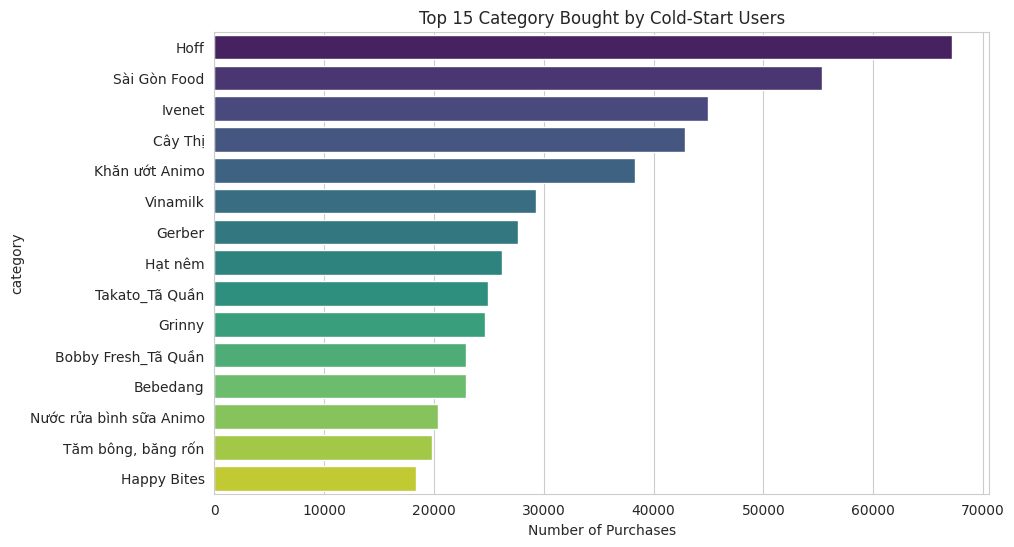

--- Top Category ---
category
Hoff                       67226
Sài Gòn Food               55364
Ivenet                     44936
Cây Thị                    42854
Khăn ướt Animo             38302
Vinamilk                   29331
Gerber                     27663
Hạt nêm                    26229
Takato_Tã Quần             24888
Grinny                     24640
Bobby Fresh_Tã Quần        22939
Bebedang                   22876
Nước rửa bình sữa Animo    20367
Tăm bông, băng rốn         19789
Happy Bites                18317
Name: count, dtype: int64




/tmp/ipykernel_570245/152908171.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


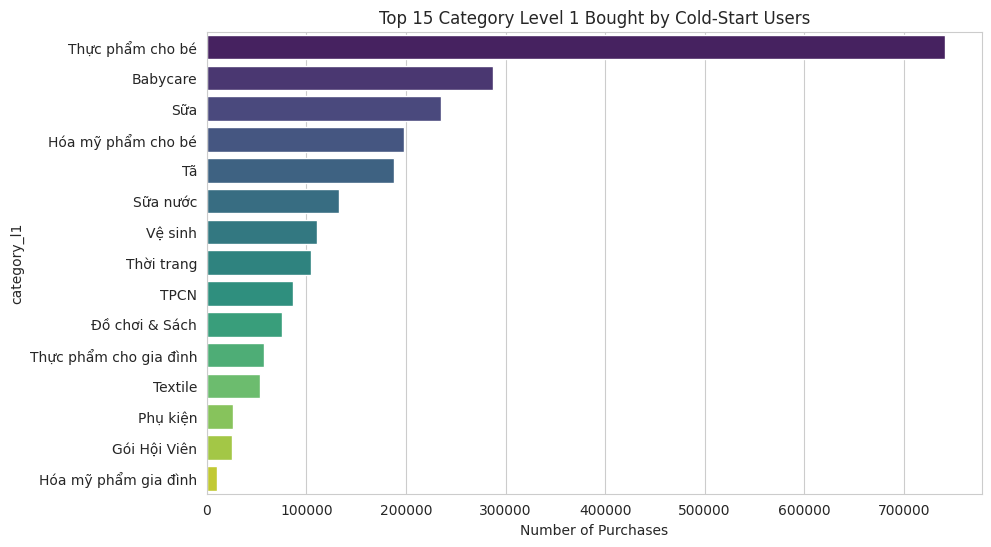

--- Top Category Level 1 ---
category_l1
Thực phẩm cho bé          741406
Babycare                  287554
Sữa                       235402
Hóa mỹ phẩm cho bé        197987
Tã                        188306
Sữa nước                  133031
Vệ sinh                   110139
Thời trang                104304
TPCN                       86957
Đồ chơi & Sách             75877
Thực phẩm cho gia đình     57838
Textile                    53469
Phụ kiện                   25854
Gói Hội Viên               24833
Hóa mỹ phẩm gia đình        9976
Name: count, dtype: int64




/tmp/ipykernel_570245/152908171.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


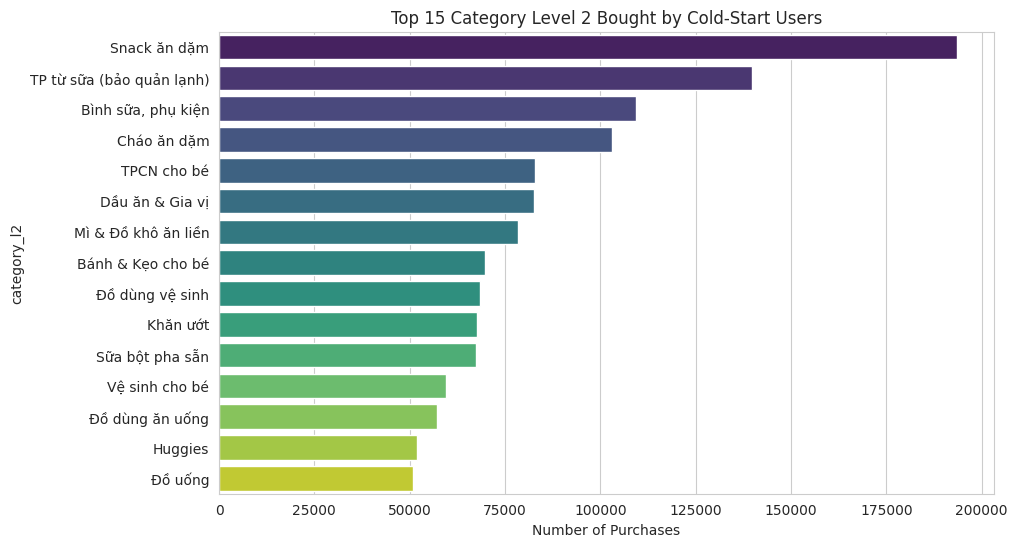

--- Top Category Level 2 ---
category_l2
Snack ăn dặm                 193565
TP từ sữa (bảo quản lạnh)    139676
Bình sữa, phụ kiện           109340
Cháo ăn dặm                  102996
TPCN cho bé                   82729
Dầu ăn & Gia vị               82492
Mì & Đồ khô ăn liền           78351
Bánh & Kẹo cho bé             69680
Đồ dùng vệ sinh               68371
Khăn ướt                      67754
Sữa bột pha sẵn               67328
Vệ sinh cho bé                59432
Đồ dùng ăn uống               57202
Huggies                       51982
Đồ uống                       50911
Name: count, dtype: int64




/tmp/ipykernel_570245/152908171.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


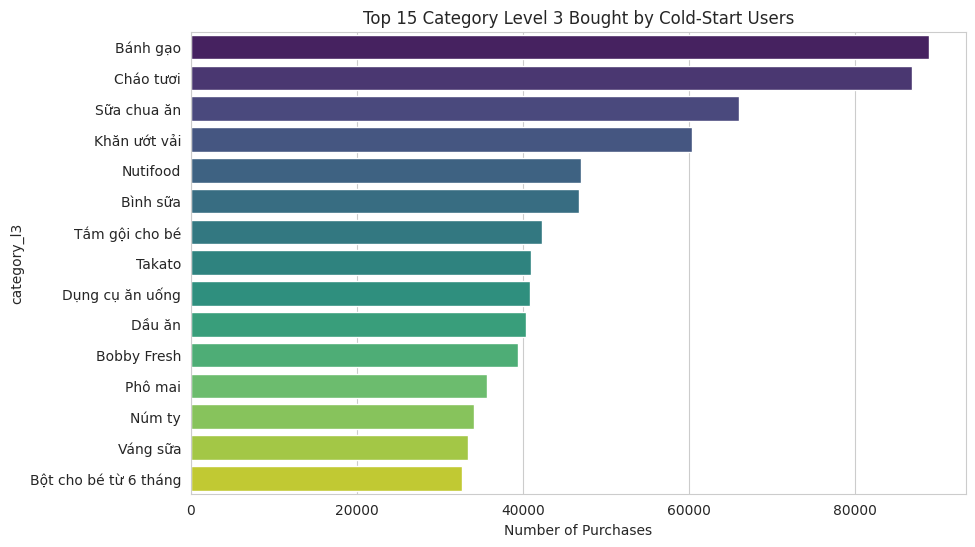

--- Top Category Level 3 ---
category_l3
Bánh gạo                 88888
Cháo tươi                86888
Sữa chua ăn              66051
Khăn ướt vải             60314
Nutifood                 46967
Bình sữa                 46784
Tắm gội cho bé           42241
Takato                   40940
Dụng cụ ăn uống          40819
Dầu ăn                   40374
Bobby Fresh              39349
Phô mai                  35625
Núm ty                   34109
Váng sữa                 33425
Bột cho bé từ 6 tháng    32625
Name: count, dtype: int64




/tmp/ipykernel_570245/152908171.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


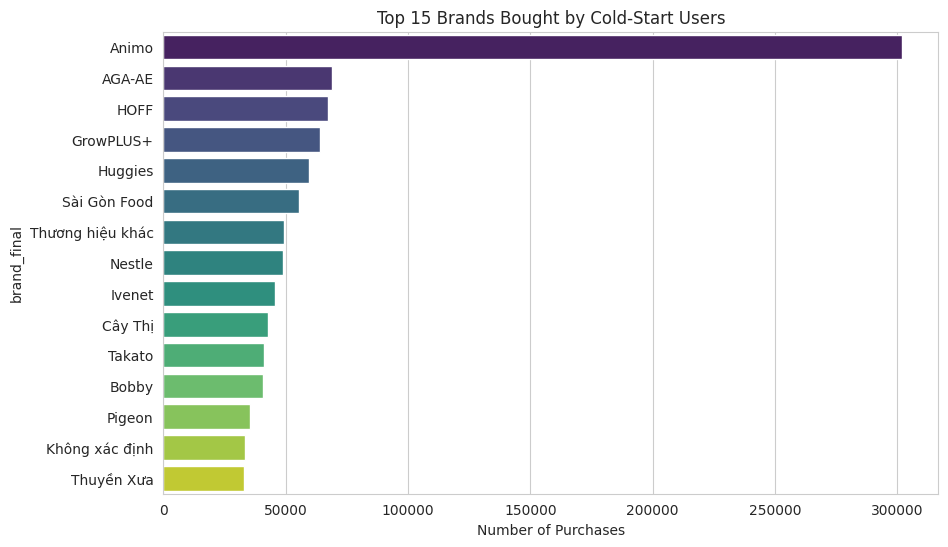

--- Top Brands ---
brand_final
Animo               301775
AGA-AE               69079
HOFF                 67226
GrowPLUS+            64108
Huggies              59422
Sài Gòn Food         55364
Thương hiệu khác     49368
Nestle               49033
Ivenet               45738
Cây Thị              42854
Takato               40940
Bobby                40812
Pigeon               35448
Không xác định       33309
Thuyền Xưa           32834
Name: count, dtype: int64




/tmp/ipykernel_570245/152908171.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


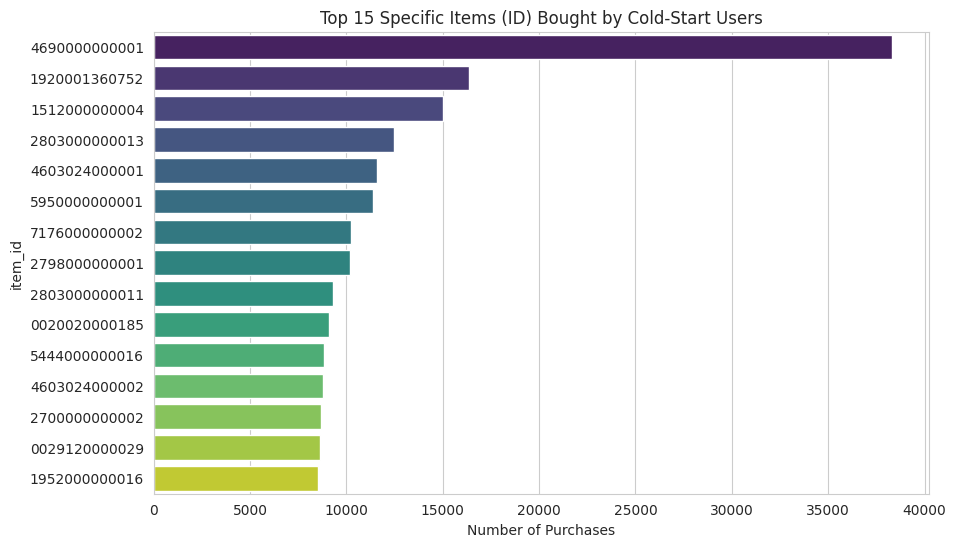

--- Top Specific Items (ID) ---
item_id
4690000000001    38301
1920001360752    16389
1512000000004    15032
2803000000013    12492
4603024000001    11605
5950000000001    11358
7176000000002    10252
2798000000001    10201
2803000000011     9319
0020020000185     9088
5444000000016     8823
4603024000002     8762
2700000000002     8700
0029120000029     8615
1952000000016     8523
Name: count, dtype: int64




ValueError: cannot insert item_id, already exists

In [4]:
# %% [markdown]
# ### 6.1 Top Category L1 (Danh mục lớn)

# %%
plot_top_counts(df_analysis, "category", "Category")
plot_top_counts(df_analysis, "category_l1", "Category Level 1")

# %% [markdown]
# ### 6.2 Top Category L2 (Danh mục chi tiết hơn)

# %%
plot_top_counts(df_analysis, "category_l2", "Category Level 2")

plot_top_counts(df_analysis, "category_l3", "Category Level 3")
# %% [markdown]
# ### 6.3 Top Brands (Thương hiệu)

# %%
brand_col = "brand_final" if "brand_final" in df_analysis.columns else "brand"
plot_top_counts(df_analysis, brand_col, "Brands")

# %% [markdown]
# ### 6.4 Top Items (Sản phẩm cụ thể)

# %%
# Nếu dùng tên dài quá thì cắt bớt
if display_col != "item_id":
    df_analysis['short_name'] = df_analysis[display_col].astype(str).str[:50]
    plot_top_counts(df_analysis, "short_name", "Specific Items")
else:
    plot_top_counts(df_analysis, "item_id", "Specific Items (ID)")

# %% [markdown]
# ## 7. Lưu kết quả

# %%
output_path = "./cold_start_stats.csv"
# Group lại đếm số lượng cho gọn
summary = df_analysis.groupby(['item_id', display_col]).size().reset_index(name='count')
summary = summary.sort_values('count', ascending=False)
summary.to_csv(output_path, index=False)
print(f"Saved summary to {output_path}")

# Predict

In [1]:
def precision_at_k_with_ct(pred, gt, hist, filter_bought_items=True, K=10): # prediction, ground-truth, history items, candidate items
    precisions = []
    ideal_precs = []
    ncold_start = 0
    cold_start_users = []
    nusers = len(gt.keys())
    for user in gt.keys():
        if (user not in hist) or (user not in pred):
            ncold_start += 1
            cold_start_users.append(user) # THINKING: để giảm cold start có thể tăng khoảng HISTORY
            
            gt_items = gt[user]
            relevant_items = set(gt_items)
            
            hits = len(set(pred[user][:K]) & relevant_items)
            precisions.append(hits / K)
            continue
            
        gt_items = gt[user]
        relevant_items = set(gt_items)
        if filter_bought_items:
            relevant_items -=set(hist[user])
        # Compute precision@k
        hits = len(set(pred[user][:K]) & relevant_items)
        precisions.append(hits / K)
    return np.mean(precisions), cold_start_users

In [2]:
def precision_at_k(pred, gt, hist, filter_bought_items=True, K=10): # prediction, ground-truth, history items, candidate items
    precisions = []
    ideal_precs = []
    ncold_start = 0
    cold_start_users = []
    nusers = len(gt.keys())
    for user in gt.keys():
        if (user not in hist) or (user not in pred):
            ncold_start += 1
            cold_start_users.append(user) # THINKING: để giảm cold start có thể tăng khoảng HISTORY
            continue
        gt_items = gt[user]
        relevant_items = set(gt_items)
        if filter_bought_items:
            relevant_items -=set(hist[user])
        # Compute precision@k
        hits = len(set(pred[user][:K]) & relevant_items)
        precisions.append(hits / K)
    return np.mean(precisions), cold_start_users

# Load groundtruth

In [3]:
import pickle
import joblib
import os
import pandas as pd
import numpy as np

def load_groundtruth_pkl(path):
    """
    Load Ground Truth từ file .pkl và chuyển về dạng Dict {user_str: {item_str1, item_str2...}}
    Xử lý triệt để vấn đề mất số 0 ở đầu ID.
    """
    print(f">>> Loading Ground Truth from: {path}")
    if not os.path.exists(path):
        print(f"❌ File not found: {path}")
        return {}
        
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    gt_clean = {}
    
    # --- TRƯỜNG HỢP 1: DATA LÀ DATAFRAME ---
    if isinstance(data, pd.DataFrame):
        u_col, i_col = 'customer_id', 'item_id' # Sửa tên cột nếu file của bạn khác
        
        # Nếu cột item chứa list (ví dụ: [item1, item2]), dùng explode để tách dòng
        if not data.empty:
            first_val = data[i_col].iloc[0]
            if isinstance(first_val, (list, np.ndarray, set)):
                data = data.explode(i_col)
        
        # Loại bỏ NaN
        data = data.dropna(subset=[u_col, i_col])
        
        # [QUAN TRỌNG] Ép kiểu String trực tiếp
        data[u_col] = data[u_col].astype(str)
        data[i_col] = data[i_col].astype(str)
        
        # Group lại thành dictionary: User -> Set(Items)
        gt_clean = data.groupby(u_col)[i_col].apply(set).to_dict()
        
    # --- TRƯỜNG HỢP 2: DATA LÀ DICTIONARY ---
    elif isinstance(data, dict):
        # Unwrap nếu dict lồng nhau (thường gặp khi save metrics)
        for k in ['gt_test', 'test', 'groundtruth', 'val']:
            if k in data: 
                data = data[k]
                break
                
        # Duyệt và ép kiểu
        for u, v in data.items():
            u_str = str(u) # Key user luôn là string
            
            # Value items có thể là list, set, array hoặc 1 giá trị đơn
            if isinstance(v, (list, tuple, set, np.ndarray)):
                items_set = set(str(x) for x in v) # Ép từng item trong list về string
            else:
                items_set = {str(v)}
                
            gt_clean[u_str] = items_set
            
    print(f"   [SUCCESS] Loaded {len(gt_clean)} users in Ground Truth.")
    return gt_clean

In [4]:
# Đường dẫn file (Cấu hình lại cho đúng máy bạn)
GT_PATH = "./data/final_groundtruth.pkl"

# 1. Load GT
gt_dict = load_groundtruth_pkl(GT_PATH)


>>> Loading Ground Truth from: ./data/final_groundtruth.pkl


/tmp/ipykernel_2907504/1774646416.py:18: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


   [SUCCESS] Loaded 644970 users in Ground Truth.


# Load trans

In [5]:
import pandas as pd
import glob
import os
from tqdm.auto import tqdm

def load_transaction_history(data_dir, file_pattern="*purchase_history*.parquet"):
    """
    Load lịch sử giao dịch (User + Item) từ raw transaction.
    
    Returns:
        dict: {user_id (str): {item_id (str), ...}} 
        Dictionary chứa lịch sử mua hàng của từng user.
    """
    search_path = os.path.join(data_dir, file_pattern)
    files = glob.glob(search_path)
    
    if not files:
        print(f"❌ Không tìm thấy file transaction nào tại: {search_path}")
        return {}
    
    print(f">>> Loading History from {len(files)} transaction files...")
    
    # Dùng list để gom dataframe con, nhanh hơn là update dict liên tục
    dfs = []
    
    for f in tqdm(files, desc="Scanning Transactions"):
        try:
            # 1. Thử đọc chỉ 2 cột cần thiết
            # try-except để xử lý trường hợp file bị thiếu cột item_id
            df = pd.read_parquet(f, columns=["customer_id", "item_id"])
            
            # 2. Xử lý dữ liệu thô ngay lập tức
            # Drop NA để tránh lỗi
            df = df.dropna(subset=["customer_id", "item_id"])
            
            # [QUAN TRỌNG] Ép kiểu string ngay lập tức để giữ số 0 (ví dụ '00123')
            df["customer_id"] = df["customer_id"].astype(str)
            df["item_id"] = df["item_id"].astype(str)
            
            # Chỉ giữ các cặp (user, item) duy nhất trong file này để giảm RAM
            df = df.drop_duplicates()
            
            dfs.append(df)
            
        except Exception as e:
            # Bỏ qua file lỗi (ví dụ thiếu cột, file hỏng) nhưng in ra để biết
            # print(f"⚠️ Skip file {os.path.basename(f)}: {e}")
            continue
            
    if not dfs:
        print("❌ Không đọc được dữ liệu hợp lệ nào!")
        return {}

    # 3. Gộp tất cả Dataframe con lại
    print("   -> Concatenating & Grouping...")
    full_df = pd.concat(dfs, ignore_index=True)
    
    # 4. Chuyển đổi thành Dictionary: User -> Set(Items)
    # Cách này nhanh hơn vòng lặp for thủ công rất nhiều
    history_dict = full_df.groupby("customer_id")["item_id"].apply(set).to_dict()
    
    warm_user_count = len(history_dict)
    print(f"   [DONE] Loaded history for {warm_user_count:,} warm users.")
    
    return history_dict

/datastore/uittogether/tools/miniconda3/envs/MABe/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
hist = load_transaction_history("./data/preprocessed-dataset-news")
hist

>>> Loading History from 80 transaction files...


Scanning Transactions: 100%|██████████| 80/80 [00:46<00:00,  1.70it/s]


   -> Concatenating & Grouping...
   [DONE] Loaded history for 2,569,978 warm users.


{'1000002': {'0020010000210', '0199000000002', '2852000000005'},
 '1000005': {'0007160000078',
  '1386000000005',
  '1735000000009',
  '1764000000002',
  '5951000000003'},
 '1000007': {'0007010000814',
  '2278000000028',
  '3944000000373',
  '7176000000002'},
 '1000010': {'2404000000006', '6501000000006'},
 '1000011': {'1386000000008',
  '4639000000004',
  '5339000000004',
  '5490000000008'},
 '1000019': {'1452000000007',
  '2017000000039',
  '3509000000037',
  '4006000000030',
  '4013000000029',
  '4294000000066',
  '5471000000002',
  '6994000000004'},
 '1000021': {'0175000000009', '3944000000220', '3944000000223'},
 '1000024': {'0007090000359',
  '1371000000003',
  '1434000000001',
  '1434000000002',
  '1452000000007',
  '1606000000003',
  '2426000000002',
  '3775000000003',
  '4048000000008',
  '4684000000001',
  '4877000000003',
  '5444000000011',
  '5826000000006',
  '5949000000017',
  '7219000000002'},
 '1000035': {'1237000000009', '3518000000076', '4027000000041'},
 '1000036': {

# Predict pkl

In [25]:
import pickle
import numpy as np
from config.settings import get_path
# 1. Load Prediction Files
path_new = get_path("/datastore/uittogether/LuuTru/Thanhld/CS116-DoAn/Phase-2/Pipeline-training3/Thanh/Filltered-item.pkl")
# path_all = get_path("/datastore/uittogether/LuuTru/Thanhld/CS116-DoAn/Phase-2/Pipeline-training3/Thanh/UNFilltered-item.pkl")

with open(path_new, "rb") as f: pred_new = pickle.load(f)
# with open(path_all, "rb") as f: pred_all = pickle.load(f)

print(f"✅ Loaded Predictions: New Items ({len(pred_new)} users), All Items ({len(pred_all)} users)")

✅ Loaded Predictions: New Items (644970 users), All Items (644970 users)


In [26]:
pred, cold = precision_at_k_with_ct(pred_new, gt_dict, hist, filter_bought_items=True, K=10)
pred

np.float64(0.01881947997581283)

In [27]:
pred, cold = precision_at_k(pred_new, gt_dict, hist, filter_bought_items=True, K=10)
pred

np.float64(0.018480190687317925)

In [10]:
pred, cold = precision_at_k_with_ct(pred_all, gt_dict, hist, filter_bought_items=False, K=10)
pred

np.float64(0.058211854814952634)

In [12]:
pred, cold = precision_at_k(pred_all, gt_dict, hist, filter_bought_items=False, K=10)
pred

np.float64(0.06832354066328582)

# Predict csv

In [26]:
import pandas as pd
import os

def load_predictions_from_csv(file_path):
    """
    Đọc file CSV prediction, giữ nguyên định dạng ID (không mất số 0),
    và chuyển đổi thành Dictionary {user_id: [item1, item2, ...]} đã sort theo score.
    """
    print(f"📂 Reading CSV from: {file_path}")
    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return {}

    # [QUAN TRỌNG] dtype=str để ép kiểu ngay lúc đọc, tránh mất số 0
    df = pd.read_csv(file_path, dtype={'customer_id': str, 'item_id': str})
    
    # Chuẩn hóa tên cột (đề phòng file csv đặt tên khác chút)
    # Giả sử cột điểm số là 'pred_score' hoặc 'score'
    score_col = 'pred_score' if 'pred_score' in df.columns else 'score'
    
    # Sắp xếp theo User và Score giảm dần (để lấy Top K chuẩn nhất)
    if score_col in df.columns:
        df = df.sort_values(by=['customer_id', score_col], ascending=[True, False])
    
    # Group lại thành Dictionary: User -> List Items
    # Dùng apply(list) để gom item lại
    pred_dict = df.groupby('customer_id')['item_id'].apply(list).to_dict()
    
    print(f"   ✅ Loaded {len(pred_dict)} users from CSV.")
    return pred_dict

In [28]:
# --- CẤU HÌNH ĐƯỜNG DẪN ---
# Sửa lại tên file csv của bạn cho đúng
PATH_CSV_NEW = get_path("/datastore/uittogether/LuuTru/Thanhld/CS116-DoAn/Phase-2/Pipeline-training3/Thanh/submission_jan2025_new_coldfixed.csv") 
PATH_CSV_ALL = get_path("/datastore/uittogether/LuuTru/Thanhld/CS116-DoAn/Phase-2/Pipeline-training3/Thanh/submission_jan2025_all_coldfixed.csv")

# 1. Load Predictions từ CSV
pred_new = load_predictions_from_csv(PATH_CSV_NEW)
pred_all = load_predictions_from_csv(PATH_CSV_ALL)

📂 Reading CSV from: /datastore/uittogether/LuuTru/Thanhld/CS116-DoAn/Phase-2/Pipeline-training3/Thanh/submission_jan2025_new_coldfixed.csv
   ✅ Loaded 644970 users from CSV.
📂 Reading CSV from: /datastore/uittogether/LuuTru/Thanhld/CS116-DoAn/Phase-2/Pipeline-training3/Thanh/submission_jan2025_all_coldfixed.csv
   ✅ Loaded 644970 users from CSV.


In [29]:
pred, cold = precision_at_k_with_ct(pred_new, gt_dict, hist, filter_bought_items=True, K=10)
pred

np.float64(0.027671674651534164)

In [30]:
pred, cold = precision_at_k_with_ct(pred_all, gt_dict, hist, filter_bought_items=False, K=10)
pred

np.float64(0.07510721428903668)

In [31]:
pred, cold = precision_at_k(pred_new, gt_dict, hist, filter_bought_items=True, K=10)
pred

np.float64(0.029668553267874483)

In [32]:
pred, cold = precision_at_k(pred_all, gt_dict, hist, filter_bought_items=False, K=10)
pred

np.float64(0.08968895602617044)